<a href="https://colab.research.google.com/github/Ram0kr0singh/DeepLeaning_Lab_Assignment3/blob/main/2501940002_Ram_Kumar_Singh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 : Import Libararies

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 2 : Load Dataset

In [2]:
# Load IMDB dataset
vocab_size = 12000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Test samples: 25000


# 3 : Padding Sequence

In [3]:
# Pad sequences to fixed length
max_len = 250

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 250)


# 4 : GRU Model

In [4]:
gru_model = Sequential()

gru_model.add(Embedding(vocab_size, 128, input_length=max_len))
gru_model.add(GRU(64))
gru_model.add(Dropout(0.5))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 5 : Train GRU Model

In [5]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 171s 427ms/step - accuracy: 0.7924 - loss: 0.4346 - val_accuracy: 0.8656 - val_loss: 0.3221
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 172s 440ms/step - accuracy: 0.9053 - loss: 0.2460 - val_accuracy: 0.8638 - val_loss: 0.3189
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 187s 478ms/step - accuracy: 0.9399 - loss: 0.1671 - val_accuracy: 0.8779 - val_loss: 0.3221
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 176s 449ms/step - accuracy: 0.9616 - loss: 0.1099 - val_accuracy: 0.8698 - val_loss: 0.3495
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 165s 422ms/step - accuracy: 0.9780 - loss: 0.0681 - val_accuracy: 0.8688 - val_loss: 0.4576
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 199s 415ms/step - accuracy: 0.9863 - loss: 0.0446 - val_accuracy: 0.8682 - val_loss: 0.5044


# 6 : LSTM Model

In [6]:
lstm_model = Sequential()

lstm_model.add(Embedding(vocab_size, 128, input_length=max_len))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 7 : Train LSTM Model

In [7]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 402ms/step - accuracy: 0.7963 - loss: 0.4372 - val_accuracy: 0.8589 - val_loss: 0.3388
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 406ms/step - accuracy: 0.8982 - loss: 0.2640 - val_accuracy: 0.8526 - val_loss: 0.3443
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 156s 398ms/step - accuracy: 0.8992 - loss: 0.2426 - val_accuracy: 0.8311 - val_loss: 0.4114
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 165s 422ms/step - accuracy: 0.9062 - loss: 0.2346 - val_accuracy: 0.8677 - val_loss: 0.3618
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 167s 427ms/step - accuracy: 0.9539 - loss: 0.1306 - val_accuracy: 0.8636 - val_loss: 0.4163
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 168s 430ms/step - accuracy: 0.9676 - loss: 0.0986 - val_accuracy: 0.8580 - val_loss: 0.5610


# 8 : Accuracy Plot

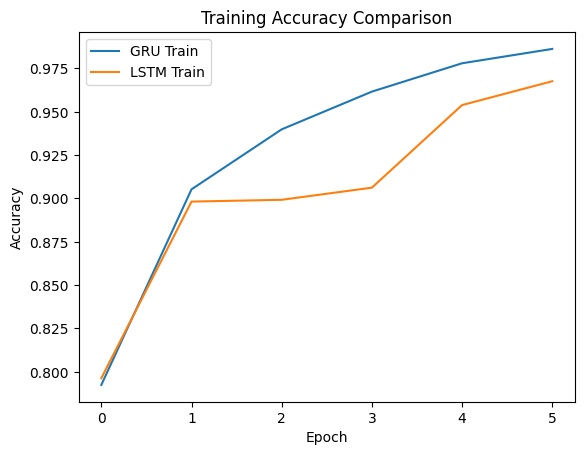

In [8]:
plt.plot(history_gru.history['accuracy'], label='GRU Train')
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 9 : Loss Plot

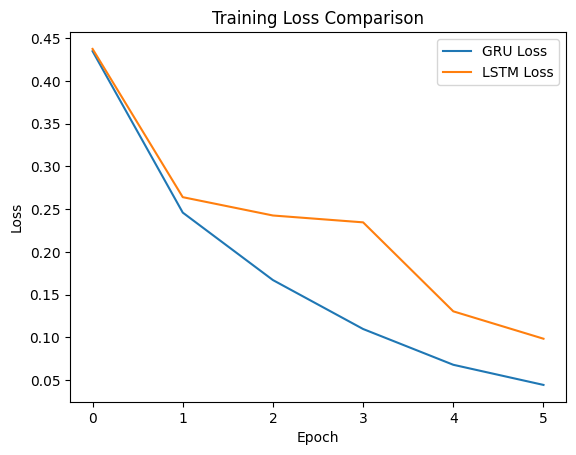

In [9]:
plt.plot(history_gru.history['loss'], label='GRU Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 10. Model Evaluation

In [10]:
# Predictions using LSTM
y_pred = (lstm_model.predict(X_test) > 0.5)

print("Classification Report (LSTM):")
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step
Classification Report (LSTM):
              precision    recall  f1-score   support

           0       0.90      0.81      0.85     12500
           1       0.82      0.91      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



# 11 : Confusion Matrix

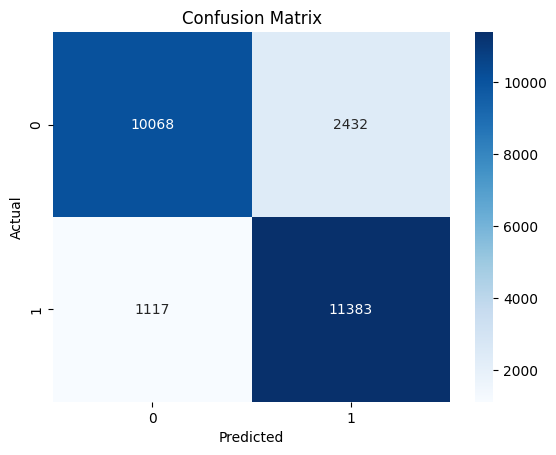

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()